In [51]:
import pandas as pd
import yaml
import re
import matplotlib.pyplot as plt

In [52]:
users = pd.read_csv("data/DATA2/users.csv")
orders = pd.read_parquet("data/DATA2/orders.parquet")

with open("data/DATA2/books.yaml", "r") as file:
    books_data = yaml.safe_load(file)

books = pd.DataFrame(books_data)

In [53]:
books.columns = books.columns.str.replace(':', '')

In [54]:
df = orders.merge(users, left_on='user_id', right_on='id')
df = df.merge(books, left_on='book_id', right_on='id')

# remove dublicates
df = df.drop_duplicates()

In [55]:
def clean_price(x):
    if pd.isna(x):
        return None
    
    x = str(x)
    x = x.replace('¢', '.')
    x = re.sub(r'[^0-9.]', '', x)
    
    try:
        return float(x)
    except:
        return None

df['unit_price'] = df['unit_price'].apply(clean_price)

In [56]:
df['timestamp'] = df['timestamp'].astype(str)

df['timestamp'] = df['timestamp'].str.replace(';', ':')
df['timestamp'] = df['timestamp'].str.replace(',', ' ')
df['timestamp'] = df['timestamp'].str.replace('A.M.', 'AM')
df['timestamp'] = df['timestamp'].str.replace('P.M.', 'PM')

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

/var/folders/wn/yv_4s6ys35z6ldk5d54s1k6h0000gn/T/ipykernel_36771/3410544006.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)


In [57]:
df = df.dropna(subset=['unit_price', 'timestamp'])

In [58]:
def clean_price_and_currency(x):
    if pd.isna(x):
        return None
    
    x = str(x).upper()
    
    # loop to spot which currencty it is
    is_eur = '€' in x or 'EUR' in x
    
    # still going on the loop if there's any cents
    x = x.replace('¢', '.')
    
    # replacing
    x = re.sub(r'[^0-9.]', '', x)
    
    try:
        price = float(x)
        
        # THAT's the condition if it's EUR we * to 1.2
        if is_eur:
            price *= 1.2
            
        return price
    
    except:
        return None


df['unit_price'] = df['unit_price'].apply(clean_price_and_currency)


# df[['unit_price']].head(10)

In [59]:
df['paid_price'] = df['quantity'] * df['unit_price']

In [60]:
df['date'] = df['timestamp'].dt.date

In [61]:
daily_revenue = df.groupby('date')['paid_price'].sum()
top5_days = daily_revenue.sort_values(ascending=False).head(5)

print(top5_days)

date
2024-12-24    38089.96
2024-08-29    37302.19
2024-11-29    34966.20
2024-12-29    33532.43
2025-01-30    32400.24
Name: paid_price, dtype: float64


In [62]:
df['user_key'] = (
    df['email'].fillna('') +
    df['phone'].fillna('') +
    df['address'].fillna('')
)

unique_users = df['user_key'].nunique()

print(unique_users)

2592


In [63]:
df['author_set'] = df['author'].apply(
    lambda x: tuple(sorted([a.strip() for a in x.split(',')]))
)

unique_author_sets = df['author_set'].nunique()

print(unique_author_sets)

293


In [64]:
popular_authors = (
    df.groupby('author_set')['quantity']
    .sum()
    .sort_values(ascending=False)
)

print(popular_authors.head(1))

author_set
(Adrian Stroman PhD, Hilario Legros I, Marco Cormier, Morton Goodwin I)    134
Name: quantity, dtype: int32


In [65]:
top_customer = (
    df.groupby('user_key')['paid_price']
    .sum()
    .sort_values(ascending=False)
)

print(top_customer.head(1))

user_key
makeda.wiza@larson.example528.261.7440Suite 336 392 Mueller Courts, Wolffurt, WY 63109-2156    33120.0
Name: paid_price, dtype: float64


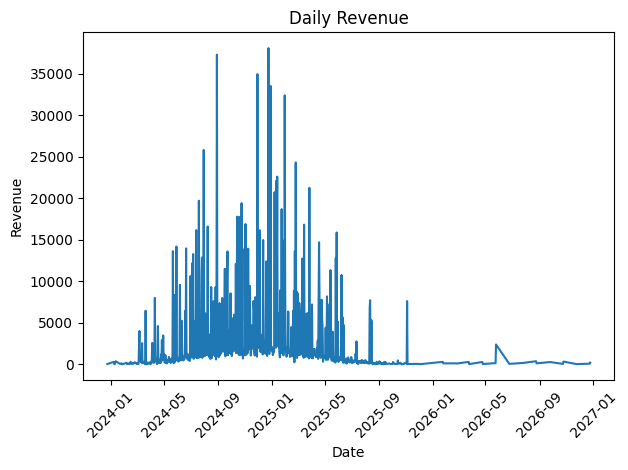

In [66]:
daily_revenue.plot()
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
df.to_csv("final_DATA2.csv", index=False)